In [1]:
## 2026.02.11 using FineST env
## 2026.02.12 vilization cell type of each ROI
## 2026.03.04 woody_pro:: upload the HE-StarDist embedding and predict the cell type of NCRT_tumor1  
## 2026.03.06 woody_pro:: clearn code 
## 2026.03.13 update cell type level1: nanually make codex_meta_celltype_level1.csv 
## 2026.03.16 use valis to make registration [dont try]
## 2026.03.18 delete two subtypes, adjust scale factor by batch
## 2026.03.19 Train and using NCRT_train.ipynb
## 2026.03.23 Adjust file name and path, then adjust model to use level1 and level2, make model_train_validate.ipynb
## 2026.04.04 woody_pro: SeededNTM; make processing for x, add cv in training for tumor1

In [2]:
import os
# Before other imports: PyTorch/torch.distributed may use /tmp; set NCRT_TMPDIR if quota is tight.
_nrtc_tmp = os.environ.get("NCRT_TMPDIR", os.path.join(os.path.expanduser("~"), "ssd2", "tmp"))
try:
    os.makedirs(_nrtc_tmp, exist_ok=True)
    os.environ["TMPDIR"] = _nrtc_tmp
    os.environ["TEMP"] = _nrtc_tmp
    os.environ["TMP"] = _nrtc_tmp
    import tempfile as _tf_nb
    _tf_nb.tempdir = _nrtc_tmp
except OSError:
    pass

import sys
import importlib
import pandas as pd
from pathlib import Path

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
code_dir = f'{path}Hist2Pheno/code/Hist2Pheno_pkg/'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

## Import (or reload) base module
import base
import plot
import model
## Impost：Force reload base.py
importlib.reload(base)  
importlib.reload(plot)  
importlib.reload(model)

## Re-import the function (otherwise, still be old_version).
from base import (
    get_celltype_coords,
    divide_into_rois_by_parent,
    get_pixel_size,
    visualize_roi_cells,
    visualize_all_rois_with_he,
    visualize_all_rois,
    extract_and_save_celltype_by_tumorid,
    transformation_matrix_properties,
    invert_transformation_matrix,
    align_pcf_to_he_coordinates,
    add_pixel_coords,
    verify_transformation_alignment,
    merge_coordinates,
    analyze_and_filter_classes_by_gap,
    ImprovedMLPClassifier,
    load_embeddings,
    match_embeddings,
    prepare_matched_embeddings,
    evaluate,
    create_dataloaders,
    train_model,
    CellTypeDataset,
    evaluate_and_plot_on_all_data,
    align_matrix,
    match_StarCoords2ROI,
    match_celltype2stardist,
    merge_celltype_level12,
    make_PCF2HE_alignment,
    load_cell_pixcoords,load_hist_embeddings,
    match_hist2cell_matrix,
    make_PCF2HE2StarDist_alignment,
    save_hce_validation_metrics,
    split_train_test,
    prepare_data_leave_one_group_out,
    spatial_tile_groups_for_logo,
    loader_train_test
    
)

from plot import (
    plot_celltype_distribution,
    visualize_all_celltype_distributions,
    plot_celltype_distribution,
    plot_celltype_spatial_distribution,
    plot_PCF_HE_counts,
    plot_WSI_counts,
    plot_cell_area_histogram,
    plot_confusion_matrix,
    plot_level1_spatial_distribution,
    plot_per_class_f1,
    plot_per_class_accuracy,
    plot_level1_accuracy_from_level2_predictions
)

from model import (
    build_mlp_classifier,
    get_best_checkpoint_path,
    train_and_save_model,
    infer_input_dim_and_num_classes,
    mode_validation,
    load_model_for_predict,
    train_and_save_model_from_split,
    mode_validation_from_split,
    train_hce_leave_one_group_out_cv,
    run_logo_cv_and_load_best_model,
    report_logo_cv_means_and_insample_eval,
    run_logo_cv_with_insample_report,
)

## Import HAS_OPENSLIDE and HAS_TIFFFILE from base module for use in notebook
HAS_OPENSLIDE = base.HAS_OPENSLIDE
HAS_TIFFFILE = base.HAS_TIFFFILE

## Also import openslide module if available (needed for direct use in some cells)
if HAS_OPENSLIDE:
    import openslide
else:
    openslide = None

try:
    import tifffile
except ImportError:
    tifffile = None

print("Successfully reloaded functions from base.py")
print(f"openslide: {HAS_OPENSLIDE}, tifffile: {HAS_TIFFFILE}")


## reset pathway
os.chdir(f'{path}Hist2Pheno/data/CODEX/ESCC')
therapy_data = 'NCRT'
image_feature = f'sc_{therapy_data}'
therapy_model = f'{therapy_data}_project_tumor1'
segment_data1 = f'{therapy_data}_project - seg 1-14'
segment_data2 = f'{therapy_data}_project - seg 15-28'
export_data = 'export'
save_result = 'result'

stardist_data = 'StarDist_Segment'
transfer_data = 'he_cell_coords'
qupath_corner = 'QupathCorners'

Successfully reloaded functions from base.py
openslide: False, tifffile: True


In [3]:
## CUDA/CPU sanity check for training setup
import os
import sys
import torch

# Default physical GPU index 2 (torch device string cuda:2). Override without editing:
#   export NCRT_CUDA_DEVICE=0
CUDA_DEVICE_INDEX = int(os.environ.get("NCRT_CUDA_DEVICE", "2"))

print(sys.executable)
print(
    f"torch {torch.__version__} | built with CUDA: {torch.version.cuda} | "
    f"cuda.is_available: {torch.cuda.is_available()}"
)

if torch.cuda.is_available():
    n_gpu = torch.cuda.device_count()
    if CUDA_DEVICE_INDEX < 0 or CUDA_DEVICE_INDEX >= n_gpu:
        raise RuntimeError(
            f"CUDA_DEVICE_INDEX={CUDA_DEVICE_INDEX} out of range; only {n_gpu} GPU(s) visible."
        )
    torch.cuda.set_device(CUDA_DEVICE_INDEX)
    device = torch.device(f"cuda:{CUDA_DEVICE_INDEX}")
    # Reproducibility-first: use deterministic cuDNN settings.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    amp_scaler = torch.amp.GradScaler("cuda")  # AMP only on CUDA
    print(
        f"Using device cuda:{CUDA_DEVICE_INDEX} | "
        f"{torch.cuda.get_device_name(CUDA_DEVICE_INDEX)}"
    )
else:
    allow_cpu = os.environ.get("NCRT_ALLOW_CPU_TRAIN", "").strip().lower() in ("1", "true", "yes")
    if allow_cpu:
        device, amp_scaler = torch.device("cpu"), None
        print("WARNING: CUDA unavailable, training on CPU (set NCRT_ALLOW_CPU_TRAIN=1).")
    else:
        raise RuntimeError(
            "CUDA unavailable. Please use a CUDA-enabled PyTorch build, "
            "or set NCRT_ALLOW_CPU_TRAIN=1 to run on CPU."
        )

if device.type == "cuda":
    print(f"device: {device} | {torch.cuda.get_device_name(CUDA_DEVICE_INDEX)}")
else:
    print(f"device: {device}")



## Reproducibility setup (run this first after kernel restart)
import os
import random
import numpy as np
import torch

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
# Needed by CUDA for deterministic GEMM on some ops.
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Enforce deterministic behavior (may reduce speed).
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

print(f"Reproducibility configured with SEED={SEED}")

/ssd2/users/lingyu/conda_envs/SeededNTM/bin/python
torch 2.9.1+cu130 | built with CUDA: 13.0 | cuda.is_available: True
Using device cuda:2 | NVIDIA RTX PRO 6000 Blackwell Server Edition
device: cuda:2 | NVIDIA RTX PRO 6000 Blackwell Server Edition
Reproducibility configured with SEED=42


## Cell Type Classification Model

Leave-one-group-out (LOGO) CV (sklearn `LeaveOneGroupOut` idea).  
Uses npz `matched_features_tumor1_logo.npz` with a `TumorID` column when available. If that column is constant for all rows (typical for tumor1-only CSV), the notebook **falls back to spatial tiles** on `X_pix_HE`×`Y_pix_HE` (`spatial_tile_groups_for_logo`).

In [4]:
## Match embeddings with celltype data by coordinates
cell_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_tumor1.csv'
hist_embedding_dir = Path(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/ImgEmbeddings_tumor1/sc_pth_16_16')
# LOGO needs per-cell groups in the npz; use a dedicated cache file (first run builds it).
matched_features_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/matched_features_tumor1_logo.npz'
LOGO_GROUP_COL = "TumorID"

# Coordinate matching tolerance in pixels (float supported).
# base.py now handles optional `celltype_level1` automatically.
match_tolerance = 1.0
X, y, y_level1, X_coords_matched, groups = match_hist2cell_matrix(
    cell_coords_path,
    hist_embedding_dir,
    matched_features_path,
    coord_cols=('X_pix_HE', 'Y_pix_HE'),
    tolerance=match_tolerance,
    pth_prefix=image_feature,
    group_col=LOGO_GROUP_COL,
    return_groups=True,
)
if groups is None:
    raise ValueError(
        f"No 'groups' in {matched_features_path}. Remove that npz and re-run once so "
        f"{LOGO_GROUP_COL!r} is written, or check the CSV column name."
    )

# Within tumor1 CSV, TumorID is often a single constant (e.g. "NCRT_tumor1") — LOGO needs ≥2 groups.
import numpy as np

LOGO_SPATIAL_NX, LOGO_SPATIAL_NY = 2, 2
_n_grp = int(np.unique(groups).size)
if _n_grp < 2:
    groups = spatial_tile_groups_for_logo(
        X_coords_matched[:, 0],
        X_coords_matched[:, 1],
        nx=LOGO_SPATIAL_NX,
        ny=LOGO_SPATIAL_NY,
    )
    print(
        f"LOGO_GROUP_COL={LOGO_GROUP_COL!r} has only {_n_grp} unique value(s); "
        f"using spatial_tile_groups_for_logo(nx={LOGO_SPATIAL_NX}, ny={LOGO_SPATIAL_NY}) on X_pix_HE/Y_pix_HE."
    )
_n_final = int(np.unique(groups).size)
print(f"LOGO: {_n_final} unique groups, {len(groups)} cells")
if _n_final < 2:
    raise ValueError(
        "Still fewer than 2 LOGO groups after spatial tiling; check coordinates or use another group_col."
    )

Loading celltype Ground Truth ...
  Loaded 80303 cells
  Cell types: 40 unique types

  ✓ matched_features cache found; skipping .pth directory load.
Loading pre-saved matched data...
  ✓ Loaded from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/matched_features_tumor1_logo.npz
  X shape: (80303, 384)
  y shape: (80303,)
  Number of classes: 40
  ✓ Coordinates found in saved data
  ✓ Coordinates loaded: (80303, 2)
LOGO_GROUP_COL='TumorID' has only 1 unique value(s); using spatial_tile_groups_for_logo(nx=2, ny=2) on X_pix_HE/Y_pix_HE.
LOGO: 4 unique groups, 80303 cells


In [5]:
# Same L2 rare-class filtering as split_train_test, but keep all rows for LOGO (no 70/30 split).
cv_data = prepare_data_leave_one_group_out(X, y, y_level1, groups)

class_names = cv_data["class_names"]
class_names_level1 = cv_data["class_names_level1"]
le_level2 = cv_data["le_level2"]
le_level1 = cv_data["le_level1"]

# Scaler fit on all filtered cells (for spatial plots / full-data eval with one checkpoint).
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(cv_data["X_f"])

# Coordinates aligned with cv_data rows (same mask as rare-L2 filtering)
X_coords_plot = (
    X_coords_matched[cv_data["mask"]] if X_coords_matched is not None else None
)

# Optional: single random 70/30 split for comparison with LOGO
RUN_RANDOM_TRAIN_TEST_SPLIT = False
if RUN_RANDOM_TRAIN_TEST_SPLIT:
    result = split_train_test(X, y, y_level1)
else:
    result = None


Leave-one-group-out prep (filtered data):
  Samples: 80302, features: 384
  Level2 classes: 39, Level1 classes: 7
  Groups (for LOGO): 4 unique


In [6]:
# LOGO：训练与评估由 ``run_logo_cv_with_insample_report`` / ``train_hce_leave_one_group_out_cv`` 内部构建 DataLoader。
# If you set RUN_RANDOM_TRAIN_TEST_SPLIT=True above, uncomment:
# loaders = loader_train_test(result, seed=SEED, train_balance_sampler=False)

loaders = None
train_loader = val_loader = val_loader_eval = None
train_dataset = val_dataset = None
X_train_scaled = y_train_encoded = y_test_encoded = None
y_train_level1_encoded = y_test_level1_encoded = None
y_encoded_f = cv_data["y_encoded_f"]
y_level1_encoded_f = cv_data["y_level1_encoded_f"]

## MLP classifier

In [7]:
## LOGO CV + best-fold model + in-sample L2/L1 report
# ``resume_from_checkpoints``（本单元格用 ``LOGO_RESUME_FROM_CHECKPOINTS``）:
#   None — 默认自动：若 ``data/.../hce_logo_fold_*.pt`` 中已有任意文件，则对每个 **已存在** 的 fold
#         跳过训练，只 load 权重并在该 fold 的 val 上算指标；缺失的 fold 仍会训练。
#         当 hce_logo_fold_0.pt, hce_logo_fold_1.pt, … 全部已齐时，所有 fold 都不会再 train。
#   True — 强制启用上述「有文件则只 load」逻辑（不依赖自动探测）。
#   False — 忽略已有 .pt，每个 fold 都重新训练。
LOGO_RESUME_FROM_CHECKPOINTS = None  # True: 明确只复用磁盘上的 fold 权重；False: 强制全量重训

hce_lambda = 0.5
LP = run_logo_cv_with_insample_report(
    device=device,
    cv_data=cv_data,
    scaler=scaler,
    class_names=class_names,
    evaluate=evaluate,
    path=path,
    therapy_data=therapy_data,
    therapy_model=therapy_model,
    hce_lambda=hce_lambda,
    patience=10,
    max_epochs=50,
    loader_kwargs={"seed": SEED, "train_balance_sampler": False},
    resume_from_checkpoints=LOGO_RESUME_FROM_CHECKPOINTS,
)
# 供后续单元格使用：logo_summary, model, val_preds, input_dim, …
globals().update(LP)


Train dataset size: 64280
Val dataset size: 16022
Batch size: 1024
Feature dimension: 384

LOGO fold 0: held-out group = 'tile_x0_y0'
  Resume: checkpoint exists, skip training → /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/hce_logo_fold_0.pt
checkpoint_exists=True: loading checkpoint (no training): /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/hce_logo_fold_0.pt
Loaded existing checkpoint metrics: accuracy=0.3283, weighted_f1=0.3148, macro_f1=0.0840
Train dataset size: 53582
Val dataset size: 26720
Batch size: 1024
Feature dimension: 384

LOGO fold 1: held-out group = 'tile_x0_y1'
  Resume: checkpoint exists, skip training → /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/hce_logo_fold_1.pt
checkpoint_exists=True: loading checkpoint (no training): /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/hce_logo_fold_1.pt
Loaded existing checkpoint metrics: accuracy=0.4464, weighted_f1=

Computing confusion matrix...


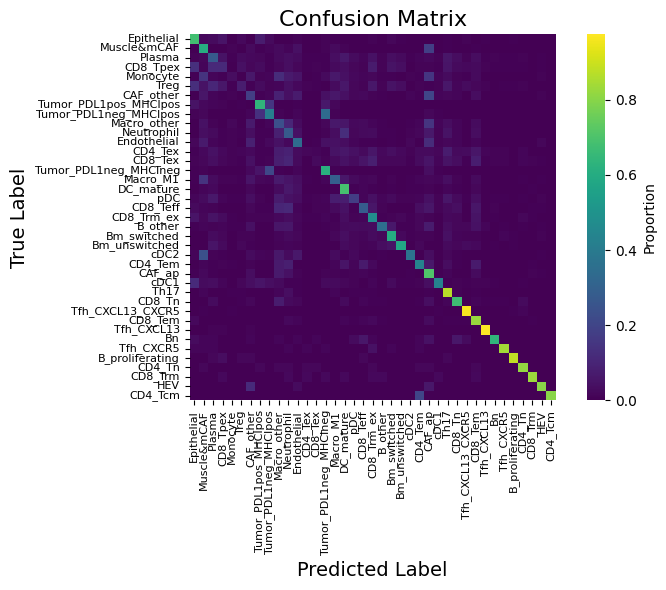

Computing confusion matrix...


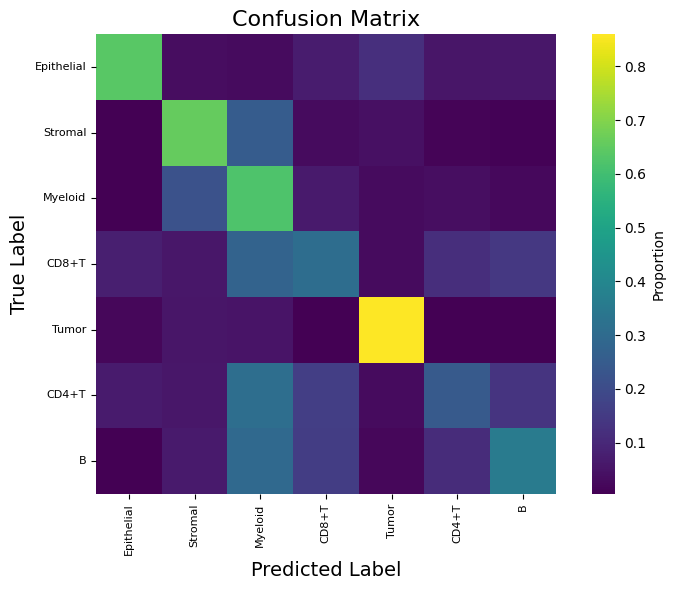

In [8]:
# Level2 confusion matrix
plot_confusion_matrix(
    val_labels,
    val_preds,
    class_names,
    # save_path=f'{therapy_data}/{save_result}/conf_matrix_tumor1_level2_hce.pdf',
    save_path=None
)

# Level1 confusion matrix
plot_confusion_matrix(
    val_labels_level1,
    val_preds_level1,
    class_names_level1,
    # save_path=f'{therapy_data}/{save_result}/conf_matrix_tumor1_level1_hce.pdf',
    save_path=None
)

In [11]:
## Save validation metrics (row = LOGO mean over folds; acc columns are NaN)
import numpy as np

metrics_csv_path = f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/hce_lambda_validation_metrics.csv"

hce_lambda_used = hce_lambda if "hce_lambda" in globals() else 0.5
mean_best_epoch = int(round(float(np.mean([f["best_epoch"] for f in logo_summary["folds"]]))))

metrics_df, combined_df = save_hce_validation_metrics(
    val_acc=float("nan"),
    val_macro_f1=logo_summary["l2_macro_f1_mean"],
    val_weighted_f1=logo_summary["l2_weighted_f1_mean"],
    val_level1_acc=float("nan"),
    val_level1_macro_f1=logo_summary["l1_macro_f1_mean"],
    val_level1_weighted_f1=logo_summary["l1_weighted_f1_mean"],
    class_names=class_names if "class_names" in globals() else None,
    class_names_level1=class_names_level1 if "class_names_level1" in globals() else None,
    best_epoch=mean_best_epoch,
    hce_lambda=hce_lambda_used,
    therapy_data=f"{therapy_data}_tumor1_LOGO",
    metrics_csv_path=metrics_csv_path,
)

Current run metrics:
             timestamp      therapy_data  best_epoch  hce_lambda  \
0  2026-04-04 20:05:44  NCRT_tumor1_LOGO          32         0.5   

   val_l2_accuracy  val_l2_macro_f1  val_l2_weighted_f1  val_l1_accuracy  \
0              NaN         0.080864            0.323628              NaN   

   val_l1_macro_f1  val_l1_weighted_f1  num_l2_classes  num_l1_classes  
0         0.309947            0.475649              39               7  

Saved comparison table to: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/result/hce_lambda_validation_metrics.csv
Total rows: 21


Visualizing per-class performance...
  ✓ Computed metrics for 39 classes


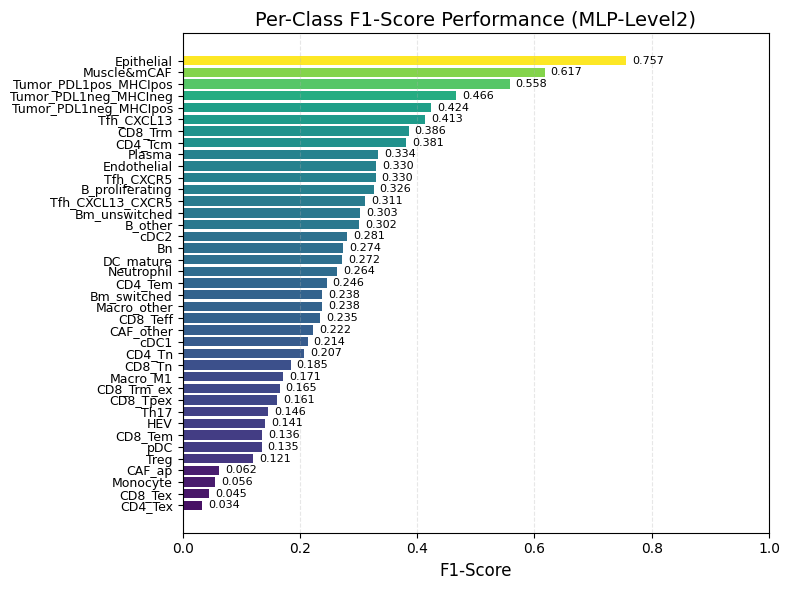


Model Summary:
  Device: cuda:2
  Total classes (before filtering): 39
  Actual classes in test set: 39
  Feature dimension: 384
  Model parameters: 1,063,975
  Best epoch: 26
  Test Accuracy: 0.3815
  Test Macro F1: 0.2688
  Test Weighted F1: 0.3836
Visualizing per-class performance...
  ✓ Computed metrics for 7 classes


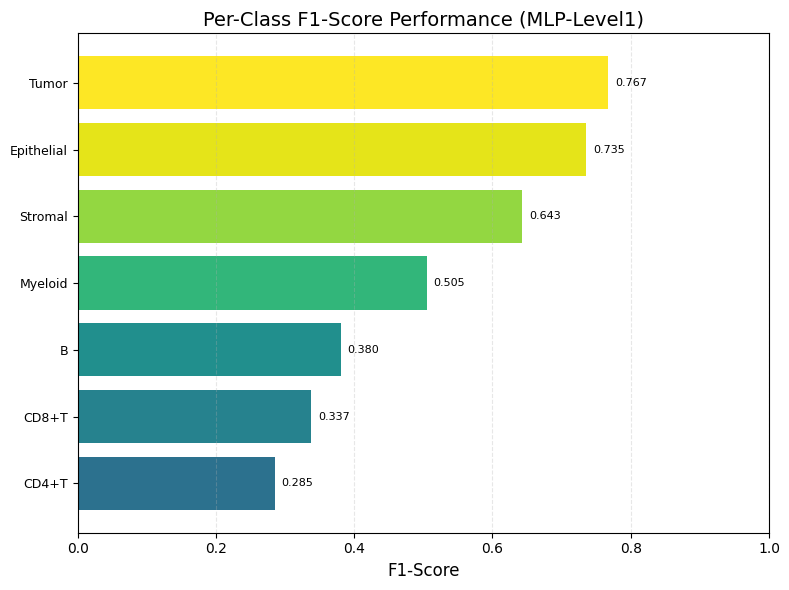


Model Summary:
  Device: cuda:2
  Total classes (before filtering): 7
  Actual classes in test set: 7
  Feature dimension: 384
  Model parameters: 1,063,975
  Best epoch: 26
  Test Accuracy: 0.5590
  Test Macro F1: 0.5218
  Test Weighted F1: 0.5549


In [12]:
# Per-class F1 for level2
metrics_df_level2 = plot_per_class_f1(
    val_labels,
    val_preds,
    class_names,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_acc,
    test_macro_f1=val_macro_f1,
    test_weighted_f1=val_weighted_f1,
    model_name="MLP-Level2",
    # save_path=f'{therapy_data}/{save_result}/f1_per_class_tumor1_level2_hce.pdf',
    save_path=None
)

# Per-class F1 for level1
metrics_df_level1 = plot_per_class_f1(
    val_labels_level1,
    val_preds_level1,
    class_names_level1,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_level1_acc,
    test_macro_f1=val_level1_macro_f1,
    test_weighted_f1=val_level1_weighted_f1,
    model_name="MLP-Level1",
    # save_path=f'{therapy_data}/{save_result}/f1_per_class_tumor1_level1_hce.pdf',
    save_path=None
)

  Using provided X and y...
  X_all_scaled shape: (80302, 384)
  y_all_encoded shape: (80302,)
  ✓ Final y_all_encoded dtype: int64
X_all_scaled:  (80302, 384)
y_all_encoded:  (80302,)
  ⚠ Large dataset detected (80302 samples). Setting num_workers=0 to avoid indexing issues.
  Total samples: 80302
  DataLoader batch_size: 1024, num_workers: 0

Final Performance on All Data:
  Accuracy: 0.3814
  Macro F1-score: 0.2688
  Weighted F1-score: 0.3835
all_preds:  (80302,)
unique_labels:  (39,)

Detailed Classification Report:
  Number of classes: 39
                       precision    recall  f1-score   support

              B_other       0.26      0.35      0.30       426
      B_proliferating       0.20      0.88      0.33        59
          Bm_switched       0.15      0.60      0.24       376
        Bm_unswitched       0.20      0.58      0.30       354
                   Bn       0.17      0.64      0.27        69
               CAF_ap       0.03      0.70      0.06       223
        

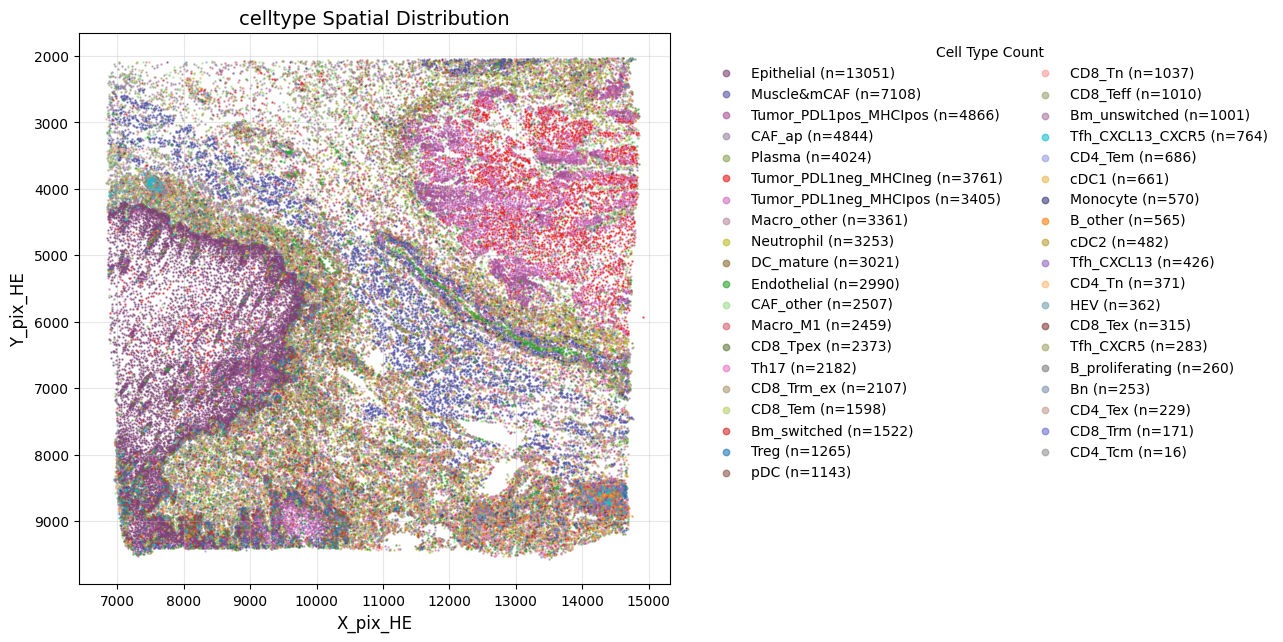


Plotting spatial distribution of TRUE cell types (for comparison)...
Number of valid data points: 80302
Number of cell types: 39


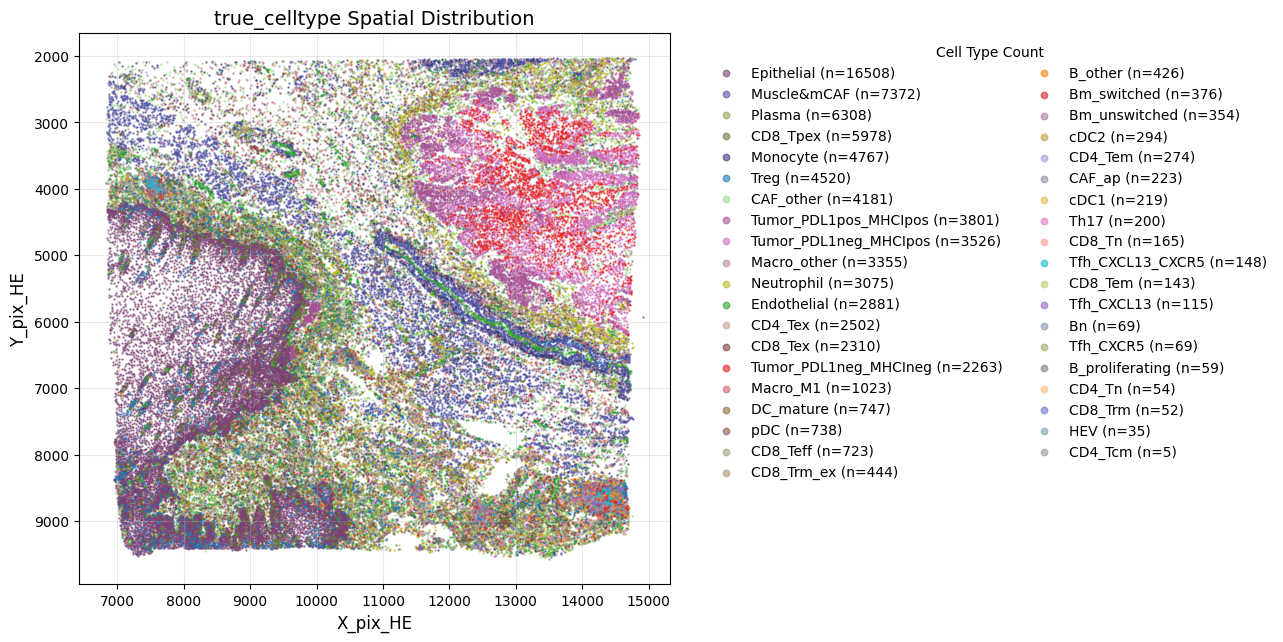

In [13]:
## Evaluate on all data and plot spatial distribution
# Skip loading npz here: rows must match ``cv_data`` filter and ``scaler`` fit on ``X_f``.
all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model,
    matched_features_path="",
    class_names=class_names,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,
    val_loader=val_loader if "val_loader" in globals() else None,
    X=cv_data["X_f"],
    y=None,
    y_encoded=cv_data["y_encoded_f"],
    X_train=None,
    X_train_scaled=X_train_scaled if "X_train_scaled" in globals() else None,
    X_test_scaled=X_test_scaled if "X_test_scaled" in globals() else None,
    y_train_encoded=y_train_encoded if "y_train_encoded" in globals() else None,
    y_test_encoded=y_test_encoded if "y_test_encoded" in globals() else None,
    min_samples_per_class=min_samples_per_class if "min_samples_per_class" in globals() else 29,
    X_coords_matched=X_coords_plot if "X_coords_plot" in globals() else None,
    # celltype_pred_dir = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/celltype_valid_tumor1_level2_hce.jpg',
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_tumor1 if "celltype_pixel_NCRT_tumor1" in globals() else None,
)

Number of valid data points: 80302
Number of cell types: 7
Number of valid data points: 80302
Number of cell types: 7


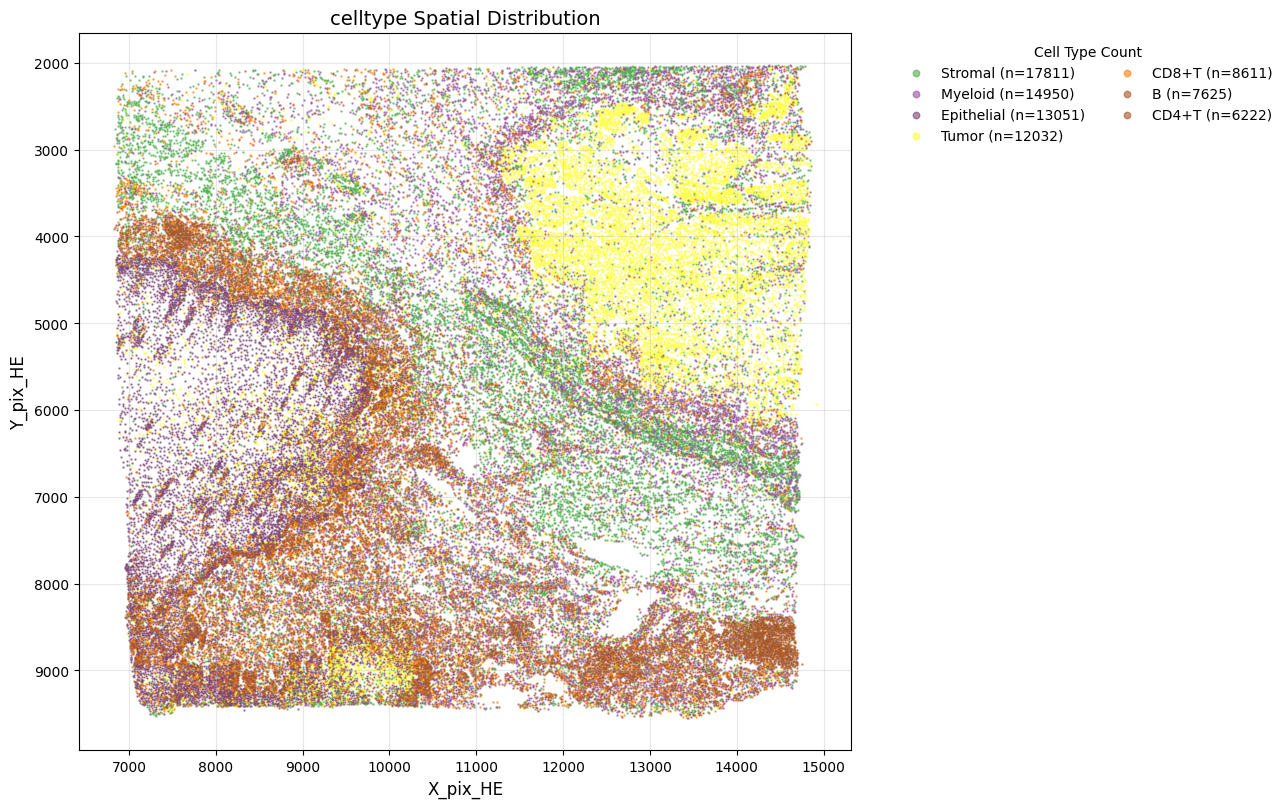

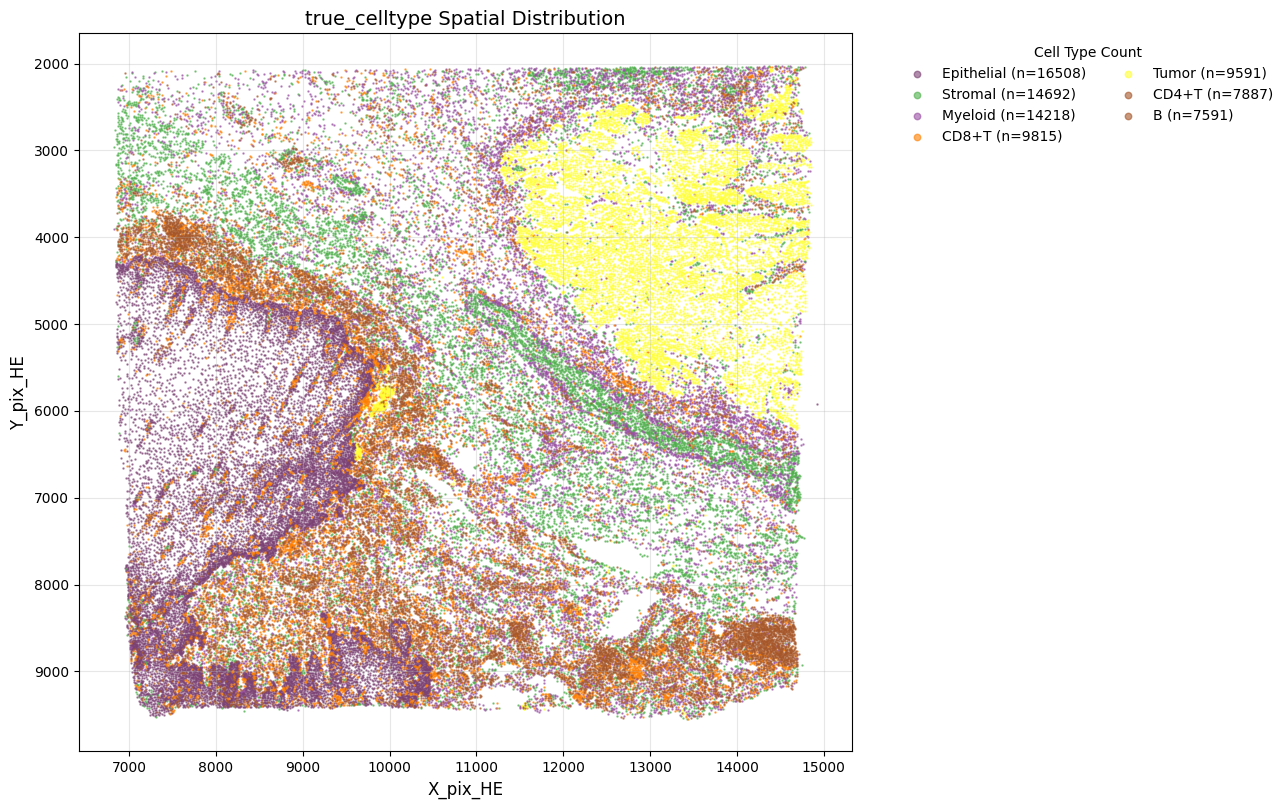

: 

In [ ]:
save_path_pred = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/celltype_valid_tumor1_level1_hce.jpg'
save_path_true = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/celltype_true_tumor1_level1_hce.jpg'
plot_level1_spatial_distribution(
    matched_features_path=matched_features_path,
    all_preds=all_preds,
    class_names_level1=class_names_level1,
    class_names=class_names,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    save_path_pred=save_path_pred,
    save_path_true=save_path_true
)